In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
import string
import requests
import socket

In [3]:


def random_string(k):
    size = random.randint(1, k)
    return ''.join(random.choices(string.ascii_lowercase, k=size))

def domain_exists(domain):
    try:
        socket.gethostbyname(domain)
        return 1
    except socket.gaierror:
        return 0

def monte_carlo_estimate(k, n):
    count = 0
    N = sum(26**i for i in range(1, k+1))
    
    for _ in range(n):
        s = random_string(k)
        domain = f"{s}.ufrj.br"  # sem http
        
        count += domain_exists(domain)
    
    p_hat = count / n
    
    return N * p_hat

In [5]:
import socket
import time

domain = "www.ufrj.br"

start = time.time()

try:
    socket.gethostbyname(domain)
    result = "existe"
except:
    result = "não existe"

end = time.time()

print(f"Domínio: {domain}")
print(f"Resultado: {result}")
print(f"Tempo: {end - start:.4f} segundos")

Domínio: www.ufrj.br
Resultado: existe
Tempo: 0.0000 segundos


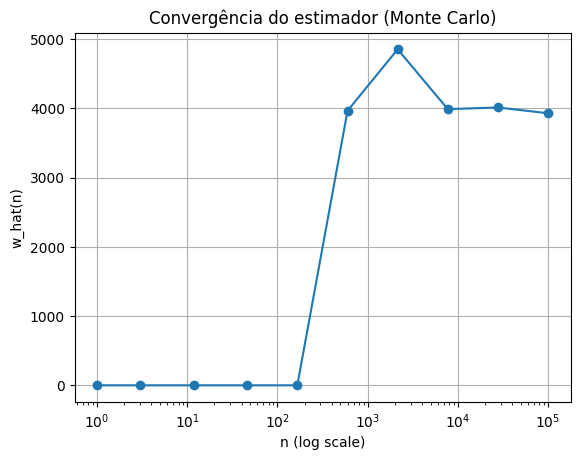

In [8]:

k = 4

# pontos em escala log (isso é o truque)
n_values = np.unique(np.logspace(0, 5, num=10, dtype=int))

w_hat_values = []

for n in n_values:
    w_hat = monte_carlo_estimate(k, n)
    w_hat_values.append(w_hat)

# gráfico semi-log
plt.figure()
plt.semilogx(n_values, w_hat_values, marker='o')
plt.xlabel("n (log scale)")
plt.ylabel("w_hat(n)")
plt.title("Convergência do estimador (Monte Carlo)")
plt.grid()
plt.show()

In [10]:
w_hat_values

[np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(3967.0617696160266),
 np.float64(4854.033426183843),
 np.float64(3990.1201239989664),
 np.float64(4013.825336927224),
 np.float64(3930.35058)]

In [9]:
n_values

array([     1,      3,     12,     46,    166,    599,   2154,   7742,
        27825, 100000])